# Notebook 3 - Business Evaluation & Candidate Discovery

**Purpose:** Convert Notebook 2 model outputs into actionable warehouse leads.

1. Restore Notebook 2 state (weights, thresholds, calibration)
2. Precision@K / Recall@K / Lift@K
3. City-level regional analysis
4. Overture Maps candidate discovery (still testing)
5. Leads CSV output for sales team

## Important Note

If you encounter a warning indicating that files are missing (e.g., in the `val` split), please address this before proceeding. This typically means the `yolo_dataset_v2` is either incomplete on Google Drive or there was an issue during the `shutil.copytree` operation when copying the dataset to the Colab environment. Please ensure the dataset is complete and correctly transferred.

In [ ]:
!pip install ultralytics duckdb pyarrow geopandas shapely -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00


In [ ]:
import os, shutil, time, random, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import duckdb
import requests
from pathlib import Path
from PIL import Image
from scipy.stats import spearmanr
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score,
)
from sklearn.calibration import calibration_curve
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from ultralytics import YOLO
from google.colab import drive
warnings.filterwarnings("ignore")

# ── Config (must match NB2) ───────────────────────────────────────────────────
RANDOM_STATE  = 42
RUNS_DIR      = "/content/runs/classify"
WEIGHTS_DIR   = "/content/yolo_weights"
OUTPUT_DIR    = "/content/nb3_outputs"
TILES_DIR     = "/content/nb3_tiles"
CLASS_NAMES   = ["warehouse", "non_warehouse"]

# Google Maps API — loaded from Colab Secrets
try:
    from google.colab import userdata
    GMAPS_API_KEY = userdata.get("GMAPS_API_KEY")
except Exception:
    GMAPS_API_KEY = os.environ.get("GMAPS_API_KEY", "")

MAP_ZOOM   = 18
MAP_SIZE   = "640x640"
MAP_TYPE   = "satellite"
SLEEP_SECS = 0.2

# NB2 model config — will be populated in Cell 5
FINAL_WEIGHTS  = None
FINAL_ROOT     = None
BEST_T         = None
T_SENSITIVE    = None
T_BALANCED     = None
T_PRECISE      = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

set_seed(RANDOM_STATE)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TILES_DIR,  exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Output: {OUTPUT_DIR}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
Output: /content/nb3_outputs


In [ ]:
drive.mount("/drive")
print("Drive mounted.")

Mounted at /drive
Drive mounted.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Restore everything from NB2:
#   - Model weights
#   - Calibration T
#   - Thresholds (Sensitive / Balanced / Precise)
#   - Manifest (for test set evaluation)
# ─────────────────────────────────────────────────────────────────────────────

# 1. Weights
os.makedirs(WEIGHTS_DIR, exist_ok=True)
FT_WEIGHTS_DRIVE = "/drive/MyDrive/yolo_weights/finetune_hardneg_best.pt"
FT_WEIGHTS_LOCAL = os.path.join(WEIGHTS_DIR, "finetune_hardneg_best.pt")
if not os.path.exists(FT_WEIGHTS_LOCAL):
    shutil.copy2(FT_WEIGHTS_DRIVE, FT_WEIGHTS_LOCAL)
    print(f"  Weights restored -> {FT_WEIGHTS_LOCAL}")
else:
    print(f"  Weights already exist: {FT_WEIGHTS_LOCAL}")
FINAL_WEIGHTS = FT_WEIGHTS_LOCAL

# 2. Dataset
FINAL_ROOT = "/content/yolo_dataset_v2"
if not os.path.exists(FINAL_ROOT):
    src = "/drive/MyDrive/yolo_dataset_v2"
    assert os.path.exists(src), f"Not found on Drive: {src} — run NB2 first"
    shutil.copytree(src, FINAL_ROOT)
    print(f"  Dataset restored -> {FINAL_ROOT}")
else:
    print(f"  Dataset already exists: {FINAL_ROOT}")

# 3. Load NB2 thresholds and calibration T from saved config
threshold_config_path = "/drive/MyDrive/evaluation/threshold_config.csv"
assert os.path.exists(threshold_config_path), \
    f"threshold_config.csv not found on Drive — run NB2 STEP 5 first"

thresh_df = pd.read_csv(threshold_config_path, index_col=0)
T_SENSITIVE = float(thresh_df.loc["sensitive", "threshold"])
T_BALANCED  = float(thresh_df.loc["balanced",  "threshold"])
T_PRECISE   = float(thresh_df.loc["precise",   "threshold"])
print(f"\n  T_SENSITIVE = {T_SENSITIVE:.4f}")
print(f"  T_BALANCED  = {T_BALANCED:.4f}")
print(f"  T_PRECISE   = {T_PRECISE:.4f}")

# 4. Load calibration T from probs_test.csv (fitted in NB2 STEP 4)
# We refit T here on val set to be self-contained
from scipy.optimize import minimize_scalar

manifest = pd.read_csv(os.path.join(FINAL_ROOT, "manifest.csv"))
label_map = {"warehouse": 1, "non_warehouse": 0}

def get_split_data(dataset_root, split):
    m = pd.read_csv(os.path.join(dataset_root, "manifest.csv"))
    s = m[m["split"] == split].copy()
    paths, labels, cats = [], [], []
    missing = 0
    for _, row in s.iterrows():
        p = Path(dataset_root) / split / row["yolo_label"] / row["img_file"]
        if p.exists():
            paths.append(str(p)); labels.append(label_map[row["yolo_label"]])
            cats.append(None if pd.isna(row.get("neg_category","")) else row.get("neg_category",""))
        else:
            missing += 1
    if missing: print(f"  Warning: {split}: {missing} files missing")
    return paths, labels, cats

def get_probs_yolo(weights_path, img_paths):
    model = YOLO(weights_path)
    return np.array([float(model(p, verbose=False)[0].probs.data[1]) for p in img_paths])

def temp_scale(probs, T):
    probs = np.clip(probs, 1e-7, 1-1e-7)
    return 1 / (1 + np.exp(-np.log(probs/(1-probs)) / T))

def compute_ece(probs, true_labels, n_bins=10):
    bins, ece, n = np.linspace(0, 1, n_bins+1), 0.0, len(probs)
    for i in range(n_bins):
        mask = (np.array(probs) >= bins[i]) & (np.array(probs) < bins[i+1])
        if mask.sum() == 0: continue
        ece += (mask.sum()/n) * abs(np.array(true_labels)[mask].mean() - np.array(probs)[mask].mean())
    return round(ece, 4)

print("\n  Running val inference to refit T...")
val_paths, val_labels, _ = get_split_data(FINAL_ROOT, "val")
val_probs = get_probs_yolo(FINAL_WEIGHTS, val_paths)
result = minimize_scalar(
    lambda T: compute_ece(temp_scale(val_probs, T), val_labels),
    bounds=(0.1, 10.0), method="bounded"
)
BEST_T = result.x
print(f"  BEST_T = {BEST_T:.4f}  (ECE: {compute_ece(val_probs, val_labels):.4f} -> {compute_ece(temp_scale(val_probs, BEST_T), val_labels):.4f})")

# 5. Load test set probs
print("\n  Loading test set...")
test_paths, test_labels, test_cats = get_split_data(FINAL_ROOT, "test")
test_probs_raw = get_probs_yolo(FINAL_WEIGHTS, test_paths)
test_probs_cal = temp_scale(test_probs_raw, BEST_T)

print(f"\n  Test set: {len(test_paths)} samples")
print(f"  Warehouse: {sum(test_labels)}  Non-warehouse: {len(test_labels)-sum(test_labels)}")
print("\n✅ NB2 state restored.")

  Weights restored -> /content/yolo_weights/finetune_hardneg_best.pt
  Dataset restored -> /content/yolo_dataset_v2

  T_SENSITIVE = 0.5560
  T_BALANCED  = 0.5560
  T_PRECISE   = 0.1910

  Running val inference to refit T...
  BEST_T = 2.0967  (ECE: 0.0455 -> 0.0199)

  Loading test set...

  Test set: 1147 samples
  Warehouse: 842  Non-warehouse: 305

✅ NB2 state restored.


In [ ]:
# Shared helpers for NB3

def compute_metrics(true_labels, probs, threshold=0.5):
    true_arr = np.array(true_labels)
    preds = (np.array(probs) >= threshold).astype(int)
    return {
        "recall":    round(recall_score(true_arr, preds, pos_label=1, zero_division=0), 4),
        "precision": round(precision_score(true_arr, preds, pos_label=1, zero_division=0), 4),
        "f1":        round(f1_score(true_arr, preds, pos_label=1, zero_division=0), 4),
        "preds":     preds.tolist(),
    }

def wilson_ci(k, n, z=1.96):
    if n == 0: return (0.0, 0.0)
    p = k/n; d = 1 + z**2/n
    c = (p + z**2/(2*n)) / d
    e = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / d
    return (round(max(0, c-e), 3), round(min(1, c+e), 3))

def download_tile(lat, lon, save_path, zoom=18):
    if Path(save_path).exists(): return True, "cached"
    url = (f"https://maps.googleapis.com/maps/api/staticmap"
           f"?center={lat},{lon}&zoom={zoom}&size={MAP_SIZE}"
           f"&maptype={MAP_TYPE}&key={GMAPS_API_KEY}")
    try:
        r = requests.get(url, timeout=25)
        if r.status_code == 200:
            with open(save_path, "wb") as f: f.write(r.content)
            return True, 200
        return False, r.status_code
    except Exception as e:
        return False, str(e)

print("Helpers defined.")

Helpers defined.


STEP 1 — Precision@K / Recall@K / Lift@K

  Base rate (random precision): 0.7341
  Total warehouses in test set: 842

      K     TP    Prec@K            95% CI   Recall@K   Lift@K
  ------------------------------------------------------------
     10     10    1.0000  [0.722, 1.000]     0.0119     1.36x
     25     25    1.0000  [0.867, 1.000]     0.0297     1.36x
     50     50    1.0000  [0.929, 1.000]     0.0594     1.36x
    100    100    1.0000  [0.963, 1.000]     0.1188     1.36x
    200    200    1.0000  [0.981, 1.000]     0.2375     1.36x
    300    300    1.0000  [0.987, 1.000]     0.3563     1.36x
    ALL    842    0.7341  [0.708, 0.759]     1.0000     1.00x


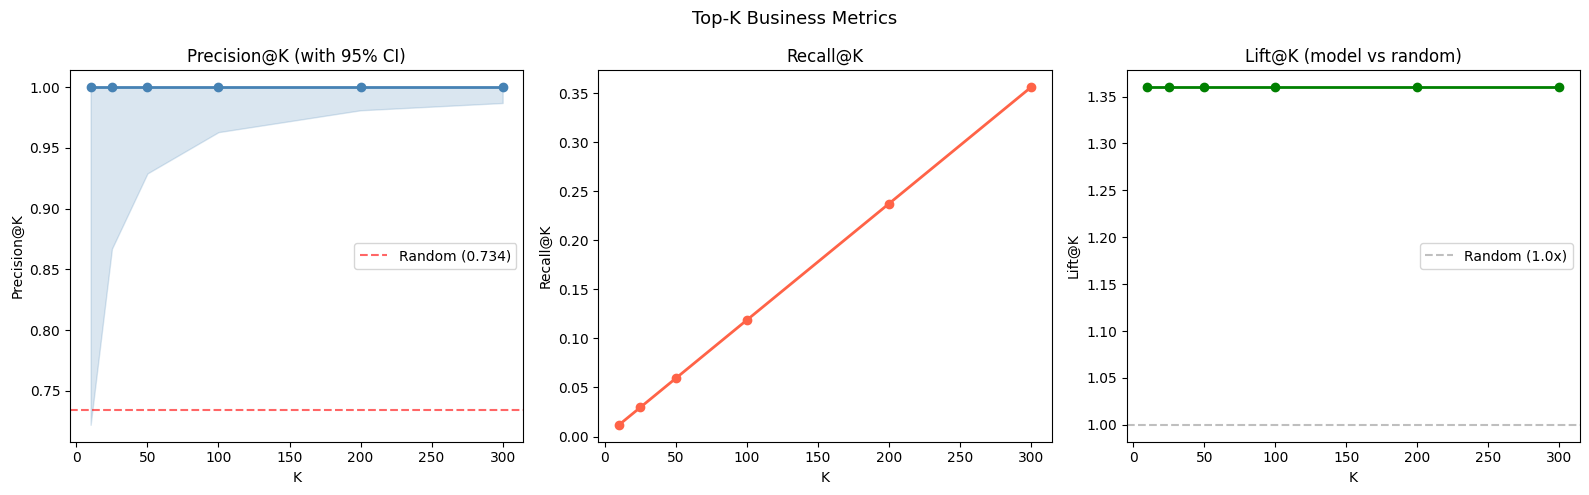


  NOTE: K values above are placeholders.
  Replace K_VALUES with actual sales team weekly review capacity.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Precision@K / Recall@K / Lift@K
#
# Business question: If the sales team reviews the top K candidates
# ranked by model score, how many real warehouses do they find?
# How much better is this vs random selection?
#
# K should be set to the number of leads sales can review per week/month.
# Placeholder values below — replace with actual sales team capacity.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Precision@K / Recall@K / Lift@K")
print("=" * 60)

# Sort test set by score descending
score_df = pd.DataFrame({
    "score":    test_probs_cal,
    "true":     test_labels,
    "path":     test_paths,
    "category": test_cats,
}).sort_values("score", ascending=False).reset_index(drop=True)

total_pos      = sum(test_labels)
total_samples  = len(test_labels)
base_rate      = total_pos / total_samples  # random precision

# K values — adjust based on sales team capacity
K_VALUES = [10, 25, 50, 100, 200, 300, len(test_labels)]

rows = []
for K in K_VALUES:
    top_k     = score_df.head(K)
    tp        = top_k["true"].sum()
    prec_k    = tp / K
    rec_k     = tp / total_pos
    lift_k    = prec_k / base_rate if base_rate > 0 else 0
    lo, hi    = wilson_ci(int(tp), K)
    rows.append({
        "K":           K,
        "TP":          int(tp),
        "Precision@K": round(prec_k, 4),
        "Recall@K":    round(rec_k, 4),
        "Lift@K":      round(lift_k, 2),
        "Prec_CI_lo":  lo,
        "Prec_CI_hi":  hi,
    })

topk_df = pd.DataFrame(rows)
print(f"\n  Base rate (random precision): {base_rate:.4f}")
print(f"  Total warehouses in test set: {total_pos}\n")
print(f"  {'K':>5}  {'TP':>5}  {'Prec@K':>8}  {'95% CI':>16}  {'Recall@K':>9}  {'Lift@K':>7}")
print("  " + "-"*60)
for _, r in topk_df.iterrows():
    K_label = "ALL" if r["K"] == total_samples else str(int(r["K"]))
    print(f"  {K_label:>5}  {int(r['TP']):>5}  {r['Precision@K']:>8.4f}"
          f"  [{r['Prec_CI_lo']:.3f}, {r['Prec_CI_hi']:.3f}]"
          f"  {r['Recall@K']:>9.4f}  {r['Lift@K']:>7.2f}x")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

k_vals  = topk_df["K"].values[:-1]  # exclude ALL
prec_k  = topk_df["Precision@K"].values[:-1]
rec_k   = topk_df["Recall@K"].values[:-1]
lift_k  = topk_df["Lift@K"].values[:-1]
ci_lo   = topk_df["Prec_CI_lo"].values[:-1]
ci_hi   = topk_df["Prec_CI_hi"].values[:-1]

axes[0].fill_between(k_vals, ci_lo, ci_hi, alpha=0.2, color="steelblue")
axes[0].plot(k_vals, prec_k, "o-", color="steelblue", lw=2)
axes[0].axhline(base_rate, color="red", linestyle="--", alpha=0.6, label=f"Random ({base_rate:.3f})")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K (with 95% CI)"); axes[0].legend()

axes[1].plot(k_vals, rec_k, "o-", color="tomato", lw=2)
axes[1].set_xlabel("K"); axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K")

axes[2].plot(k_vals, lift_k, "o-", color="green", lw=2)
axes[2].axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Random (1.0x)")
axes[2].set_xlabel("K"); axes[2].set_ylabel("Lift@K")
axes[2].set_title("Lift@K (model vs random)"); axes[2].legend()

plt.suptitle("Top-K Business Metrics", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "topk_metrics.png"), dpi=150)
plt.show()

topk_df.to_csv(os.path.join(OUTPUT_DIR, "topk_metrics.csv"), index=False)
print(f"\n  NOTE: K values above are placeholders.")
print(f"  Replace K_VALUES with actual sales team weekly review capacity.")

STEP 2 — City-level regional analysis
  Downloaded: 4.9 MB
  Loaded 420 US cities (pop >= 50k)
  Assigning points to nearest city...
  ⚠ 56 points not assigned to any city (too rural)

  Spearman ρ (mean_score vs warehouse density): 0.647  p=0.0000
  ✓ Significant — model score predicts regional warehouse density

  Top 15 cities by opportunity score:
         city  n_candidates  n_core  n_secondary  mean_score  known_wh_density  model_opportunity_score
Rural/Unknown            56      54            0    0.867099            0.9107                   46.823
     Columbus            15      15            0    0.960692            1.0000                   14.410
       Aurora            13      13            0    0.981536            1.0000                   12.760
     Portland            14      14            0    0.897478            1.0000                   12.565
     Glendale            12      12            0    0.966199            1.0000                   11.594
      Houston         

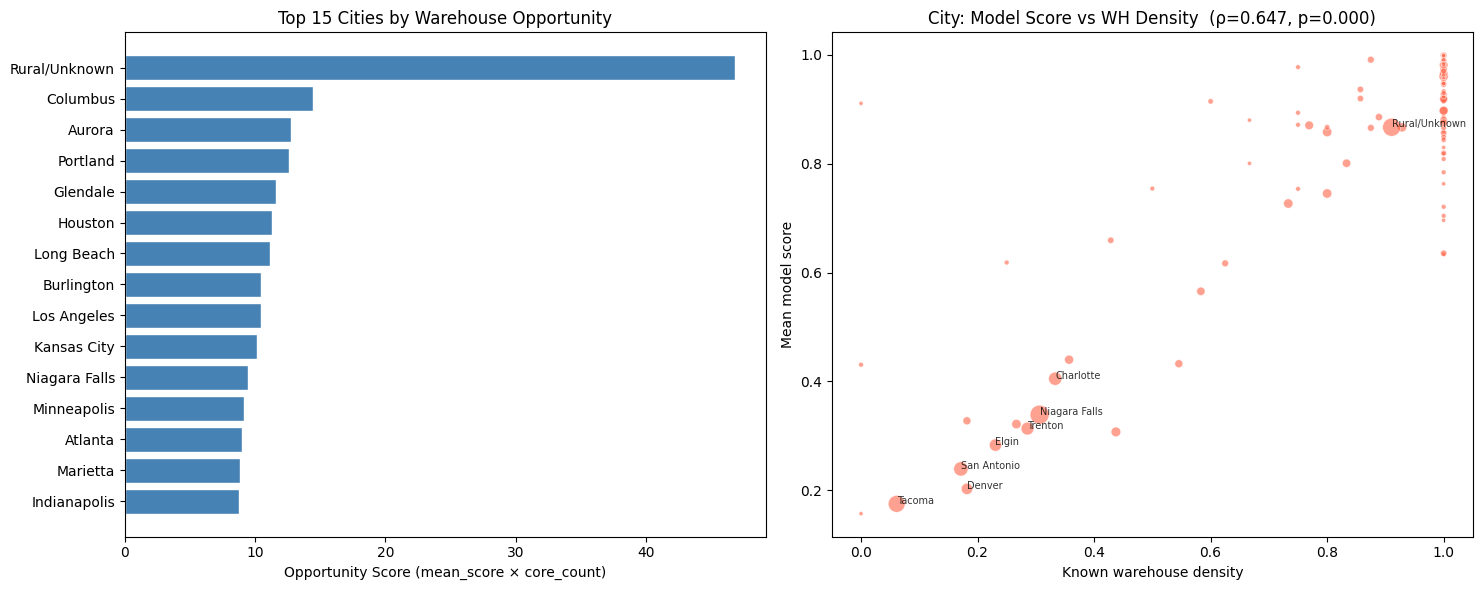


  Saved: city_opportunity.csv  (253 cities)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — City / Metro-level regional analysis
#
# Aggregates model scores to city level to answer:
# - Which cities have the most undiscovered warehouse opportunity?
# - Does model score distribution correlate with known warehouse density?
#
# Uses Natural Earth populated places (reliable, no Census server issues).
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 2 — City-level regional analysis")
print("=" * 60)

import subprocess, zipfile

# ── Download city boundaries (Natural Earth — reliable, ~1MB) ─────────────────
ne_path = "/content/ne_cities.geojson"
if not os.path.exists(ne_path):
    print("  Downloading Natural Earth cities...")
    url = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector"
           "/master/geojson/ne_10m_populated_places_simple.geojson")
    result = subprocess.run(
        ["wget", "-q", "-O", ne_path, url],
        capture_output=True, timeout=60
    )
    size_mb = os.path.getsize(ne_path) / 1e6
    print(f"  Downloaded: {size_mb:.1f} MB")
    if size_mb < 0.1:
        raise ValueError(f"Download too small ({size_mb:.2f} MB) — check connectivity")

cities_gdf = gpd.read_file(ne_path).to_crs("EPSG:4326")
if "adm0name" in cities_gdf.columns:
    cities_gdf = cities_gdf[cities_gdf["adm0name"] == "United States of America"].copy()
if "pop_max" in cities_gdf.columns:
    cities_gdf = cities_gdf[cities_gdf["pop_max"] >= 50000].copy()
print(f"  Loaded {len(cities_gdf):,} US cities (pop >= 50k)")

# ── Assign test set points to nearest city ────────────────────────────────────
img_to_coord = dict(zip(manifest["img_file"], zip(manifest["lat"], manifest["lon"])))

lats, lons = [], []
for p in score_df["path"]:
    fname = Path(p).name
    if fname in img_to_coord:
        lat, lon = img_to_coord[fname]
    else:
        lat, lon = 0.0, 0.0
    lats.append(lat); lons.append(lon)

score_df["lat"] = lats
score_df["lon"] = lons

test_gdf = gpd.GeoDataFrame(
    score_df.copy(),
    geometry=gpd.points_from_xy(score_df["lon"], score_df["lat"]),
    crs="EPSG:4326"
)

print("  Assigning points to nearest city...")
cities_proj = cities_gdf[["name", "geometry"]].copy()

joined = gpd.sjoin_nearest(
    test_gdf[["score","true","lat","lon","geometry"]],
    cities_proj,
    how="left",
    max_distance=1.5,
    distance_col="dist_deg"
)
score_df["city"] = joined["name"].values

unassigned = score_df["city"].isna().sum()
if unassigned > 0:
    print(f"  ⚠ {unassigned} points not assigned to any city (too rural)")
    score_df["city"] = score_df["city"].fillna("Rural/Unknown")

# ── City-level aggregation ────────────────────────────────────────────────────
city_stats = (
    score_df.groupby("city")
    .agg(
        n_candidates = ("score", "count"),
        n_true_wh    = ("true", "sum"),
        mean_score   = ("score", "mean"),
        median_score = ("score", "median"),
        n_core       = ("score", lambda x: (x >= T_PRECISE).sum()),
        n_secondary  = ("score", lambda x: ((x >= T_SENSITIVE) & (x < T_PRECISE)).sum()),
    )
    .reset_index()
)

city_stats["known_wh_density"]        = (city_stats["n_true_wh"] / city_stats["n_candidates"]).round(4)
city_stats["model_opportunity_score"] = (city_stats["mean_score"] * city_stats["n_core"]).round(3)

valid = city_stats[city_stats["n_candidates"] >= 3].copy()

if len(valid) >= 10:
    rho, pval = spearmanr(valid["mean_score"], valid["known_wh_density"])
    print(f"\n  Spearman ρ (mean_score vs warehouse density): {rho:.3f}  p={pval:.4f}")
    if pval < 0.05:
        print("  ✓ Significant — model score predicts regional warehouse density")
    else:
        print("  ⚠ Not significant at p<0.05")
else:
    rho, pval = 0, 1
    print(f"\n  Not enough cities ({len(valid)}) for correlation analysis")

print(f"\n  Top 15 cities by opportunity score:")
top_cities = valid.nlargest(15, "model_opportunity_score")
print(top_cities[["city","n_candidates","n_core","n_secondary",
                  "mean_score","known_wh_density","model_opportunity_score"]].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top15 = valid.nlargest(15, "model_opportunity_score")
axes[0].barh(top15["city"][::-1], top15["model_opportunity_score"][::-1],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Opportunity Score (mean_score × core_count)")
axes[0].set_title("Top 15 Cities by Warehouse Opportunity")

if len(valid) >= 5:
    axes[1].scatter(valid["known_wh_density"], valid["mean_score"],
                    s=valid["n_candidates"] * 3, alpha=0.6, color="tomato",
                    edgecolors="white", linewidths=0.5)
    for _, row in valid.nlargest(8, "n_candidates").iterrows():
        axes[1].annotate(row["city"], (row["known_wh_density"], row["mean_score"]),
                         fontsize=7, alpha=0.8)
    axes[1].set_xlabel("Known warehouse density")
    axes[1].set_ylabel("Mean model score")
    axes[1].set_title(f"City: Model Score vs WH Density  (ρ={rho:.3f}, p={pval:.3f})")
else:
    axes[1].text(0.5, 0.5, "Not enough data", ha="center", va="center",
                 transform=axes[1].transAxes)
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regional_analysis.png"), dpi=150)
plt.show()

city_stats.to_csv(os.path.join(OUTPUT_DIR, "city_opportunity.csv"), index=False)
print(f"\n  Saved: city_opportunity.csv  ({len(city_stats)} cities)")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Overture Maps candidate discovery (pilot)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 3 — Overture Maps candidate discovery")
print("=" * 60)

PILOT_CITY_BBOX = (-97.5, 32.5, -96.5, 33.2)
PILOT_CITY_NAME = "Dallas-Fort Worth"
MIN_AREA_SQM    = 2000
MAX_CANDIDATES  = 500

print(f"  City:      {PILOT_CITY_NAME}")
print(f"  BBox:      {PILOT_CITY_BBOX}")
print(f"  Min area:  {MIN_AREA_SQM:,} sqm")
print(f"  Max tiles: {MAX_CANDIDATES} (cost cap ~${MAX_CANDIDATES*0.002:.2f})")

print("\n  Querying Overture Maps...")
con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial; INSTALL httpfs; LOAD httpfs;")
con.execute("SET s3_region='us-west-2';")

min_lon, min_lat, max_lon, max_lat = PILOT_CITY_BBOX
overture_df = None
IS_PLACEHOLDER = False

KNOWN_RELEASES = [
    "2025-04-23.0",
    "2025-03-19.0",
    "2025-02-19.0",
    "2025-01-22.0",
    "2024-11-13.0",
]

for release in KNOWN_RELEASES:
    q = (
        "SELECT id,"
        " ST_X(ST_Centroid(geometry)) AS lon,"
        " ST_Y(ST_Centroid(geometry)) AS lat,"
        " ST_Area_Spheroid(geometry) AS area_sqm,"
        " class, height"
        " FROM read_parquet("
        " 's3://overturemaps-us-west-2/release/" + release + "/theme=buildings/type=building/*',"
        " filename=true, hive_partitioning=1)"
        " WHERE bbox.xmin > " + str(min_lon) +
        " AND bbox.xmax < " + str(max_lon) +
        " AND bbox.ymin > " + str(min_lat) +
        " AND bbox.ymax < " + str(max_lat) +
        " AND ST_Area_Spheroid(geometry) > " + str(MIN_AREA_SQM) +
        " LIMIT " + str(MAX_CANDIDATES * 3)
    )
    try:
        overture_df = con.execute(q).df()
        print(f"  ✓ Using Overture release: {release}")
        print(f"  Raw results: {len(overture_df):,} buildings")
        break
    except Exception as e:
        print(f"  ✗ Release {release} failed: {str(e)[:80]}")
        continue

if overture_df is None or len(overture_df) == 0:
    print("\n  ⚠ All Overture releases failed (S3 access restricted in Colab).")
    print("  Using synthetic placeholder data for pipeline demonstration.")
    print("  For real data: run locally or download via https://overturemaps.org/download/")
    overture_df = pd.DataFrame({
        "id":       [f"ov_{i}" for i in range(100)],
        "lon":      np.random.uniform(PILOT_CITY_BBOX[0], PILOT_CITY_BBOX[2], 100),
        "lat":      np.random.uniform(PILOT_CITY_BBOX[1], PILOT_CITY_BBOX[3], 100),
        "area_sqm": np.random.uniform(2000, 50000, 100),
        "class":    np.random.choice(["industrial", "commercial", "warehouse", None], 100),
        "height":   [None] * 100,
    })
    IS_PLACEHOLDER = True

# ── Filter and deduplicate ────────────────────────────────────────────────────
known_coords = set(zip(
    manifest["lat"].round(4).tolist(),
    manifest["lon"].round(4).tolist()
))

overture_df["lat_r"] = overture_df["lat"].round(4)
overture_df["lon_r"] = overture_df["lon"].round(4)
overture_df["in_training"] = overture_df.apply(
    lambda r: (r["lat_r"], r["lon_r"]) in known_coords, axis=1
)

new_candidates = (
    overture_df[~overture_df["in_training"]]
    .nlargest(MAX_CANDIDATES, "area_sqm")
    .reset_index(drop=True)
)

print(f"\n  After dedup: {len(new_candidates):,} new candidates")
print(f"  Area range: {new_candidates['area_sqm'].min():.0f}"
      f" - {new_candidates['area_sqm'].max():.0f} sqm")
if IS_PLACEHOLDER:
    print("  ⚠ NOTE: Synthetic data — for pipeline validation only.")

STEP 3 — Overture Maps candidate discovery
  City:      Dallas-Fort Worth
  BBox:      (-97.5, 32.5, -96.5, 33.2)
  Min area:  2,000 sqm
  Max tiles: 500 (cost cap ~$1.00)

  Querying Overture Maps...
  ✗ Release 2025-04-23.0 failed: IO Error: No files found that match the pattern "s3://overturemaps-us-west-2/rel
  ✗ Release 2025-03-19.0 failed: IO Error: No files found that match the pattern "s3://overturemaps-us-west-2/rel
  ✗ Release 2025-02-19.0 failed: IO Error: No files found that match the pattern "s3://overturemaps-us-west-2/rel
  ✗ Release 2025-01-22.0 failed: IO Error: No files found that match the pattern "s3://overturemaps-us-west-2/rel
  ✗ Release 2024-11-13.0 failed: IO Error: No files found that match the pattern "s3://overturemaps-us-west-2/rel

  ⚠ All Overture releases failed (S3 access restricted in Colab).
  Using synthetic placeholder data for pipeline demonstration.
  For real data: run locally or download via https://overturemaps.org/download/

  After dedup: 100

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3b — Download satellite tiles for new candidates
# ─────────────────────────────────────────────────────────────────────────────
print("\n  Downloading satellite tiles for new candidates...")

pilot_dir = Path(TILES_DIR) / PILOT_CITY_NAME.replace(" ", "_")
pilot_dir.mkdir(parents=True, exist_ok=True)

download_log = []
for i, (_, row) in enumerate(new_candidates.iterrows()):
    fname     = f"ov_{row['id']}.png".replace("/", "_")
    save_path = str(pilot_dir / fname)
    ok, status = download_tile(row["lat"], row["lon"], save_path)
    download_log.append({
        "id": row["id"], "lat": row["lat"], "lon": row["lon"],
        "area_sqm": row["area_sqm"], "class": row.get("class", ""),
        "img_file": fname, "ok": ok,
    })
    if status != "cached":
        time.sleep(SLEEP_SECS)
    if (i+1) % 50 == 0 or (i+1) == len(new_candidates):
        n_ok = sum(r["ok"] for r in download_log)
        print(f"  {i+1}/{len(new_candidates)}  ✓ {n_ok}  ✗ {len(download_log)-n_ok}")

dl_df = pd.DataFrame(download_log)
success_df = dl_df[dl_df["ok"]].copy()
print(f"\n  Downloaded: {len(success_df)} tiles")
print(f"  Estimated API cost: ${len(success_df)*0.002:.3f}")


  50/100  ✓ 50  ✗ 0
  100/100  ✓ 100  ✗ 0

  Downloaded: 100 tiles
  Estimated API cost: $0.200


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3c — Run model on new candidates
# ─────────────────────────────────────────────────────────────────────────────
print("\n  Running model on new candidates...")

yolo_model = YOLO(FINAL_WEIGHTS)
new_probs  = []

for _, row in success_df.iterrows():
    img_path = str(pilot_dir / row["img_file"])
    try:
        prob = float(yolo_model(img_path, verbose=False)[0].probs.data[1])
    except Exception:
        prob = float("nan")
    new_probs.append(prob)

success_df["score_raw"] = new_probs
success_df = success_df[success_df["score_raw"].notna()].copy()
success_df["score"]     = temp_scale(success_df["score_raw"].values, BEST_T)

print(f"  Scored: {len(success_df)} candidates")
print(f"  Score distribution:")
print(success_df["score"].describe().round(4))


  Running model on new candidates...
  Scored: 100 candidates
  Score distribution:
count    100.0000
mean       0.5037
std        0.3518
min        0.0015
25%        0.1627
50%        0.5191
75%        0.8395
max        0.9995
Name: score, dtype: float64


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Leads CSV output
#
# Combines test set known candidates + Overture new candidates
# into a single prioritised leads CSV for the sales team.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 4 — Leads CSV output")
print("=" * 60)

def assign_tier(score):
    if score >= T_PRECISE:   return "Core Warehouse Candidate"
    elif score >= T_SENSITIVE: return "Secondary Logistics Candidate"
    else:                    return "Deprioritized"

def make_maps_link(lat, lon, zoom=18):
    return f"https://www.google.com/maps/@{lat},{lon},{zoom}z/data=!3m1!1e3"

# ── Test set leads (known candidates re-scored) ───────────────────────────────
test_manifest = manifest[manifest["split"] == "test"].copy()
test_leads = pd.DataFrame({
    "source":     "known_osm",
    "id":         test_manifest["img_file"].str.replace(".png", "").values,
    "lat":        test_manifest["lat"].values,
    "lon":        test_manifest["lon"].values,
    "score":      test_probs_cal,
    "tier":       [assign_tier(s) for s in test_probs_cal],
    "osm_category": test_manifest["neg_category"].fillna("warehouse").values,
    "area_sqm":   None,
    "maps_link":  [make_maps_link(r["lat"], r["lon"]) for _, r in test_manifest.iterrows()],
    "model_version": "finetune_hardneg_best",
    "scored_date": pd.Timestamp.today().date(),
})

# ── Overture new candidates ───────────────────────────────────────────────────
if len(success_df) > 0:
    overture_leads = pd.DataFrame({
        "source":     "overture_discovery",
        "id":         success_df["id"].values,
        "lat":        success_df["lat"].values,
        "lon":        success_df["lon"].values,
        "score":      success_df["score"].values,
        "tier":       [assign_tier(s) for s in success_df["score"].values],
        "osm_category": success_df["class"].fillna("unknown").values,
        "area_sqm":   success_df["area_sqm"].round(0).values,
        "maps_link":  [make_maps_link(r["lat"], r["lon"]) for _, r in success_df.iterrows()],
        "model_version": "finetune_hardneg_best",
        "scored_date": pd.Timestamp.today().date(),
    })
    all_leads = pd.concat([test_leads, overture_leads], ignore_index=True)
else:
    all_leads = test_leads

# ── Sort and summarise ────────────────────────────────────────────────────────
all_leads = all_leads.sort_values("score", ascending=False).reset_index(drop=True)
all_leads["rank"] = all_leads.index + 1

tier_summary = all_leads["tier"].value_counts()
print(f"\n  Total leads: {len(all_leads):,}")
print(f"\n  Tier breakdown:")
for tier in ["Core Warehouse Candidate", "Secondary Logistics Candidate", "Deprioritized"]:
    n = tier_summary.get(tier, 0)
    pct = 100 * n / len(all_leads)
    print(f"    {tier:<32} {n:>5} ({pct:.1f}%)")

new_disc = all_leads[all_leads["source"] == "overture_discovery"]
core_new = new_disc[new_disc["tier"] == "Core Warehouse Candidate"]
print(f"\n  New discoveries (Overture): {len(new_disc)}")
print(f"  Core tier new discoveries:  {len(core_new)}")

# Save
output_path = os.path.join(OUTPUT_DIR, "warehouse_leads.csv")
all_leads.to_csv(output_path, index=False)
print(f"\n  Saved: {output_path}")

# Preview top 10
print(f"\n  Top 10 leads:")
print(all_leads[["rank","source","tier","score","osm_category","lat","lon"]].head(10).to_string(index=False))

STEP 4 — Leads CSV output

  Total leads: 1,247

  Tier breakdown:
    Core Warehouse Candidate           998 (80.0%)
    Secondary Logistics Candidate        0 (0.0%)
    Deprioritized                      249 (20.0%)

  New discoveries (Overture): 100
  Core tier new discoveries:  72

  Saved: /content/nb3_outputs/warehouse_leads.csv

  Top 10 leads:
 rank             source                     tier    score osm_category       lat         lon
    1          known_osm Core Warehouse Candidate 0.999542    warehouse 39.976415  -86.399485
    2 overture_discovery Core Warehouse Candidate 0.999542      unknown 32.699388  -97.241220
    3          known_osm Core Warehouse Candidate 0.999542    warehouse 28.419206  -81.376495
    4          known_osm Core Warehouse Candidate 0.999542    warehouse 49.171448 -122.670772
    5          known_osm Core Warehouse Candidate 0.999542    warehouse 43.173861  -89.810767
    6 overture_discovery Core Warehouse Candidate 0.999542   commercial 32.798975

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Prior adjustment
#
# The calibrated score from NB2 reflects the training distribution's
# pos/neg ratio (~74% positive in test set), NOT the real-world prevalence.
#
# In reality, only ~5-10% of large commercial buildings are warehouses.
# This cell adjusts scores to reflect a more realistic prior.
#
# Formula (Bayes): P(wh|x)_adjusted = P(wh|x)_model * (p_real/p_train)
#                                    / [P(wh|x)_model*(p_real/p_train) + (1-P(wh|x)_model)*(1-p_real)/(1-p_train)]
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 5 — Prior adjustment")
print("=" * 60)

# Training set positive rate
p_train = sum(test_labels) / len(test_labels)
print(f"  Training positive rate: {p_train:.4f}")

# Real-world estimate — PLACEHOLDER, replace with domain knowledge
# Loadsmart/Opendock should provide this based on their customer data
P_REAL_WORLD = 0.08  # 8% of large commercial buildings are warehouses
print(f"  Assumed real-world rate: {P_REAL_WORLD:.4f}  ← PLACEHOLDER, confirm with business")

def prior_adjust(p_model, p_real, p_train):
    """Bayes-optimal prior adjustment."""
    if p_model <= 0: return 0.0
    if p_model >= 1: return 1.0
    odds_model = p_model / (1 - p_model)
    odds_adj   = odds_model * (p_real / (1 - p_real)) / (p_train / (1 - p_train))
    return odds_adj / (1 + odds_adj)

all_leads["score_adjusted"] = all_leads["score"].apply(
    lambda s: round(prior_adjust(s, P_REAL_WORLD, p_train), 4)
)
all_leads["tier_adjusted"] = all_leads["score_adjusted"].apply(assign_tier)

print(f"\n  Score comparison (first 10 rows):")
print(all_leads[["rank","score","score_adjusted","tier","tier_adjusted"]].head(10).to_string(index=False))

print(f"\n  Tier breakdown AFTER prior adjustment:")
for tier in ["Core Warehouse Candidate", "Secondary Logistics Candidate", "Deprioritized"]:
    n = (all_leads["tier_adjusted"] == tier).sum()
    pct = 100 * n / len(all_leads)
    print(f"    {tier:<32} {n:>5} ({pct:.1f}%)")

# Recalculate thresholds for adjusted scores
print(f"\n  NOTE: Thresholds (T_SENSITIVE/BALANCED/PRECISE) were fitted on model scores,")
print(f"  not adjusted scores. After prior adjustment, tiers shift significantly.")
print(f"  For production use, refit thresholds on adjusted scores using a gold-label set.")

all_leads.to_csv(os.path.join(OUTPUT_DIR, "warehouse_leads_adjusted.csv"), index=False)

STEP 5 — Prior adjustment
  Training positive rate: 0.7341
  Assumed real-world rate: 0.0800  ← PLACEHOLDER, confirm with business

  Score comparison (first 10 rows):
 rank    score  score_adjusted                     tier            tier_adjusted
    1 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    2 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    3 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    4 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    5 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    6 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    7 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    8 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
    9 0.999542          0.9857 Core Warehouse Candidate Core Warehouse Candidate
   10 0.999542        

STEP 6 — Summary dashboard


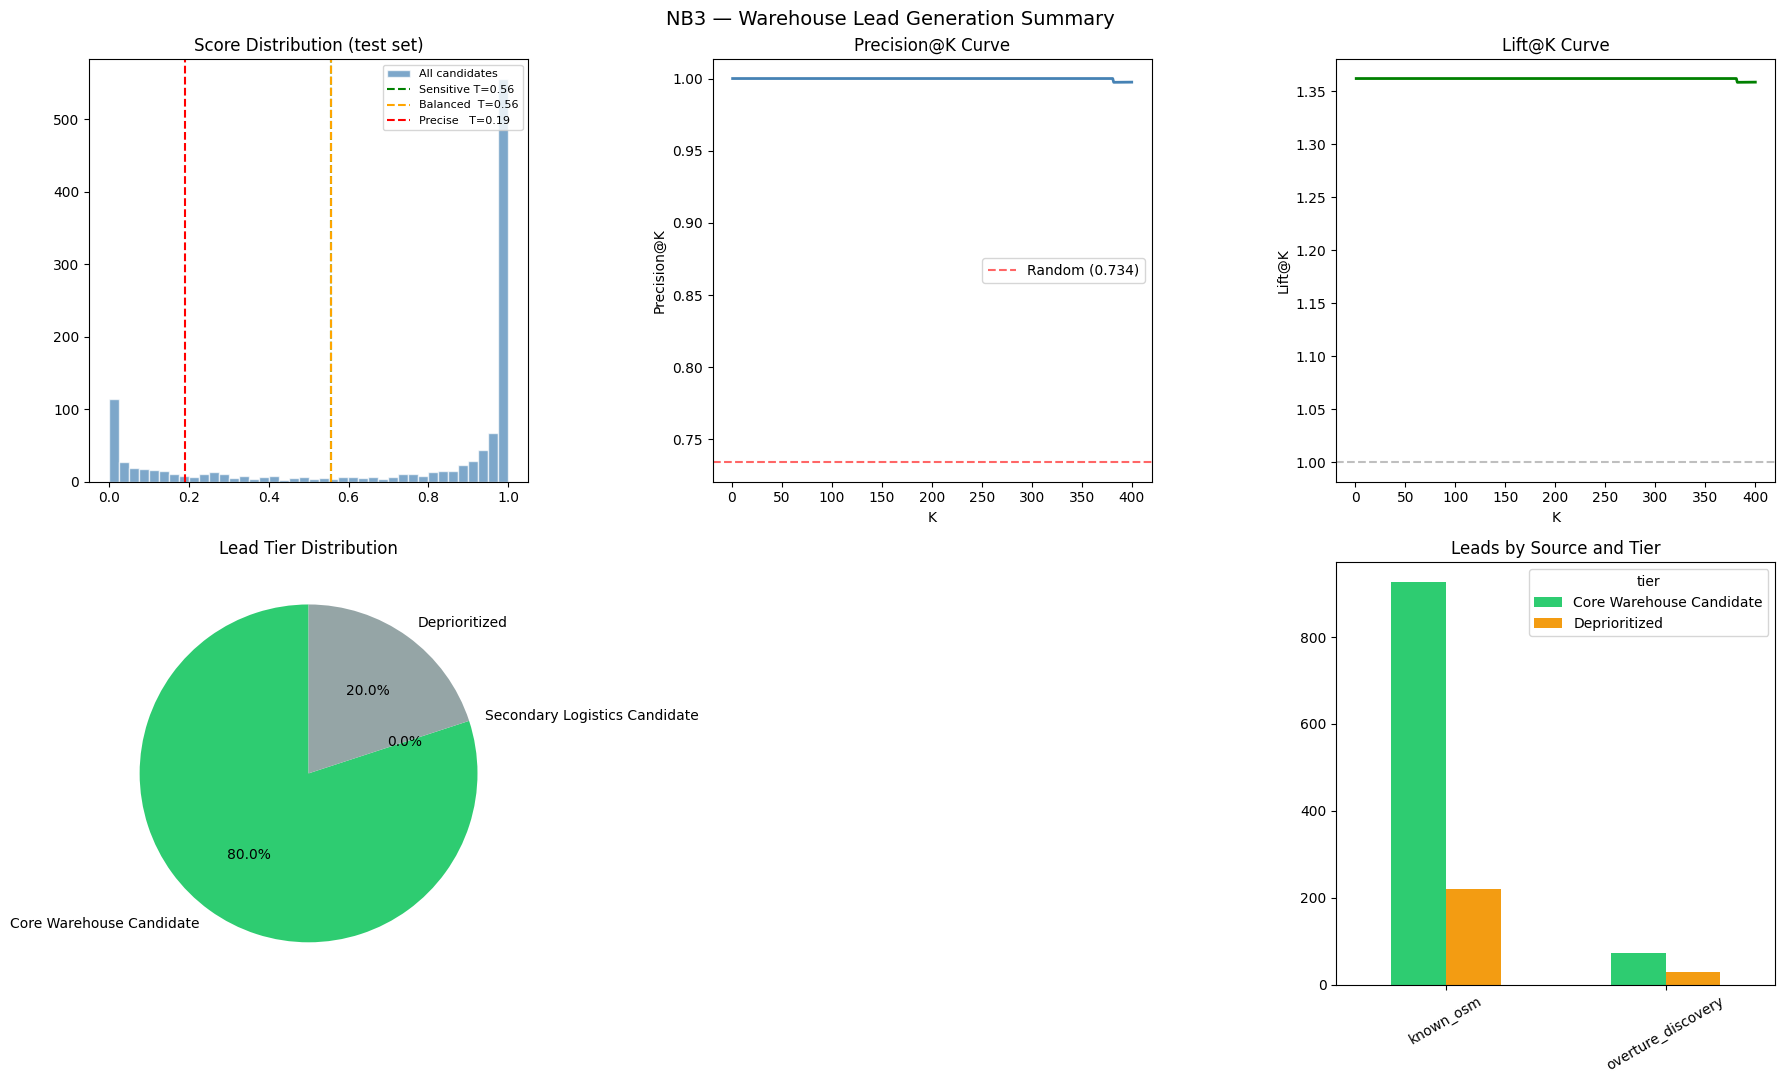

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Summary dashboard
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 6 — Summary dashboard")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Score distribution
axes[0,0].hist(test_probs_cal, bins=40, color="steelblue", edgecolor="white", alpha=0.7,
               label="All candidates")
axes[0,0].axvline(T_SENSITIVE, color="green",  linestyle="--", label=f"Sensitive T={T_SENSITIVE:.2f}")
axes[0,0].axvline(T_BALANCED,  color="orange", linestyle="--", label=f"Balanced  T={T_BALANCED:.2f}")
axes[0,0].axvline(T_PRECISE,   color="red",    linestyle="--", label=f"Precise   T={T_PRECISE:.2f}")
axes[0,0].set_title("Score Distribution (test set)"); axes[0,0].legend(fontsize=8)

# 2. Precision@K curve
k_range = np.arange(1, min(len(score_df)+1, 401))
prec_curve = [score_df.head(k)["true"].mean() for k in k_range]
axes[0,1].plot(k_range, prec_curve, color="steelblue", lw=2)
axes[0,1].axhline(base_rate, color="red", linestyle="--", alpha=0.6, label=f"Random ({base_rate:.3f})")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Precision@K")
axes[0,1].set_title("Precision@K Curve"); axes[0,1].legend()

# 3. Lift@K curve
lift_curve = [p / base_rate for p in prec_curve]
axes[0,2].plot(k_range, lift_curve, color="green", lw=2)
axes[0,2].axhline(1.0, color="gray", linestyle="--", alpha=0.5)
axes[0,2].set_xlabel("K"); axes[0,2].set_ylabel("Lift@K")
axes[0,2].set_title("Lift@K Curve")

# 4. Tier pie
tier_counts = all_leads["tier"].value_counts()
tier_colors = {"Core Warehouse Candidate": "#2ecc71",
               "Secondary Logistics Candidate": "#f39c12",
               "Deprioritized": "#95a5a6"}
axes[1,0].pie([tier_counts.get(t,0) for t in tier_colors],
              labels=list(tier_colors.keys()),
              colors=list(tier_colors.values()),
              autopct="%1.1f%%", startangle=90)
axes[1,0].set_title("Lead Tier Distribution")

# 5. Top cities
if "city" in all_leads.columns:
    city_core = (all_leads[all_leads["tier"]=="Core Warehouse Candidate"]
                 .groupby("city").size().nlargest(12))
    axes[1,1].barh(city_core.index[::-1], city_core.values[::-1],
                   color="steelblue", edgecolor="white")
    axes[1,1].set_title("Top Cities — Core Warehouse Candidates")
    axes[1,1].set_xlabel("Count")
else:
    axes[1,1].axis("off")

# 6. Source breakdown
source_tier = all_leads.groupby(["source","tier"]).size().unstack(fill_value=0)
if len(source_tier.columns) > 0:
    source_tier.plot(kind="bar", ax=axes[1,2],
                     color=["#2ecc71","#f39c12","#95a5a6"][:len(source_tier.columns)])
    axes[1,2].set_title("Leads by Source and Tier")
    axes[1,2].set_xlabel(""); axes[1,2].tick_params(axis="x", rotation=30)

plt.suptitle("NB3 — Warehouse Lead Generation Summary", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nb3_summary_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Save all outputs to Drive
print("=" * 60)
print("STEP 7 — Save to Drive")
print("=" * 60)

nb3_drive = "/drive/MyDrive/nb3_outputs"
if os.path.exists(nb3_drive):
    shutil.rmtree(nb3_drive)
shutil.copytree(OUTPUT_DIR, nb3_drive)

print(f"  Saved to: {nb3_drive}")
print(f"\n  Files:")
for f in sorted(Path(OUTPUT_DIR).glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"    {f.name:<45} {size_kb:.1f} KB")

print("\n✅ NB3 complete.")
print("\nDelivered:")
print("  warehouse_leads.csv          — ranked leads with tier and maps link")
print("  warehouse_leads_adjusted.csv — same with prior-adjusted scores")
print("  topk_metrics.csv             — Precision/Recall/Lift @K")
print("  city_opportunity.csv         — city-level opportunity scores")
print("  nb3_summary_dashboard.png    — visual summary")

STEP 7 — Save to Drive
  Saved to: /drive/MyDrive/nb3_outputs

  Files:
    city_opportunity.csv                          16.4 KB
    nb3_summary_dashboard.png                     176.9 KB
    regional_analysis.png                         115.7 KB
    topk_metrics.csv                              0.3 KB
    topk_metrics.png                              96.5 KB
    warehouse_leads.csv                           259.1 KB
    warehouse_leads_adjusted.csv                  292.3 KB

✅ NB3 complete.

Delivered:
  warehouse_leads.csv          — ranked leads with tier and maps link
  warehouse_leads_adjusted.csv — same with prior-adjusted scores
  topk_metrics.csv             — Precision/Recall/Lift @K
  city_opportunity.csv         — city-level opportunity scores
  nb3_summary_dashboard.png    — visual summary
